# Notebook 06 — Predicciones

**Proyecto:** Sistema de Predicción y Clasificación de la Desnutrición en niños menores de cinco años  
**Fase CRISP-DM:** 4 (Modelado) — Predicciones complementarias  
**Datasets:** `dataset_ml.csv`, `113_limpio_unificado.csv`, `serie_temporal_mensual.csv`, `serie_temporal_departamento.csv`

---
## Contenido

### Predicción 1 — Probabilidad de riesgo individual
- Modelo binario: desnutrido vs no desnutrido
- Salida: probabilidad entre 0% y 100%
- Curva ROC y AUC
- Comparativa con IMC vs sin IMC

### Predicción 2 — Perfil de riesgo poblacional
- ¿Qué combinación de factores genera mayor riesgo?
- Mapa de calor de riesgo por perfiles
- Identificación de grupos vulnerables

### Predicción 3 — Municipios de alto riesgo
- Ranking de municipios por tasa de desnutrición
- ¿Qué municipios necesitan intervención prioritaria?

### Predicción 4 — Evolución temporal
- Tendencia y estacionalidad 2023-2025
- Proyección 2026 con múltiples modelos
- Comparativa territorial Cesar vs La Guajira vs Magdalena

## Importación de librerías

In [18]:
import sys
!{sys.executable} -m pip install statsmodels imbalanced-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, roc_curve, brier_score_loss,
                              classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
from scipy import stats as scipy_stats

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

# Cargar datasets
df_ml   = pd.read_csv('../data/processed/dataset_ml.csv')
df_full = pd.read_csv('../data/processed/113_limpio_unificado.csv')
st      = pd.read_csv('../data/processed/serie_temporal_mensual.csv')
sd      = pd.read_csv('../data/processed/serie_temporal_departamento.csv')

# Preparar datasets
for df in [df_ml, df_full]:
    df.dropna(subset=['clas_peso'], inplace=True)
    df['clas_peso']   = df['clas_peso'].astype(int)
    df['desnutrido']  = df['clas_peso'].isin([1, 2]).astype(int)
    df['edad_meses']  = df.apply(
        lambda r: r['edad_']*12 if r['uni_med_']==1 else r['edad_'], axis=1)

st = st[st['anio_mes'] <= '2025-12'].copy()
st['fecha'] = pd.to_datetime(st['anio_mes'])
st = st.sort_values('fecha').reset_index(drop=True)
st['t'] = np.arange(len(st))

print(f'dataset_ml   : {df_ml.shape}')
print(f'dataset_full : {df_full.shape}')
print(f'serie mensual: {len(st)} puntos')
print(f'serie dpto   : {len(sd)} filas')

dataset_ml   : (2439, 55)
dataset_full : (2439, 69)
serie mensual: 36 puntos
serie dpto   : 19 filas


## Preparación del pipeline de features (reutilizable para todas las predicciones)

In [19]:
FEATURES_A = [
    'edad_meses','per_etn_','estrato_','area_','cod_dpto_o',
    'niv_educat','menores','gp_pobicbf','peso_nac','edad_ges',
    'peso_act','per_braqui','imc','t_lechem','e_complem',
    'crec_dllo','esq_vac','carne_vac',
    'edema','delgadez','palidez','piel_rese','hiperpigm',
    'cambios_cabello','ruta_atenc'
]
FEATURES_B = [f for f in FEATURES_A if f != 'imc']
COLS_ESCALAR = ['peso_act','per_braqui','t_lechem','menores',
                'peso_nac','edad_meses','imc','edad_ges','e_complem']

def preparar_pipeline(df, features):
    """Prepara X, y_bin, y_multi con encoding, imputación y escalado."""
    df_m = df[features + ['desnutrido','clas_peso']].copy()
    le = LabelEncoder()
    df_m['cod_dpto_o'] = le.fit_transform(df_m['cod_dpto_o'].astype(str))
    for col in ['niv_educat','gp_pobicbf','menores','per_braqui']:
        if col in df_m.columns:
            df_m[col] = df_m[col].fillna(df_m[col].median())
    X = df_m[features].copy()
    sc = RobustScaler()
    cols_esc = [c for c in COLS_ESCALAR if c in features]
    X[cols_esc] = sc.fit_transform(X[cols_esc])
    return X, df_m['desnutrido'], df_m['clas_peso'], sc, le

X_A, y_bin, y_multi, scaler_A, le_A = preparar_pipeline(df_ml, FEATURES_A)
X_B, _,     _,       scaler_B, le_B = preparar_pipeline(df_ml, FEATURES_B)

print(f'X_A (con IMC): {X_A.shape}')
print(f'X_B (sin IMC): {X_B.shape}')
print(f'\nDesbalance — Desnutridos: {y_bin.mean()*100:.1f}%')

X_A (con IMC): (2439, 25)
X_B (sin IMC): (2439, 24)

Desbalance — Desnutridos: 86.5%


---
# PREDICCIÓN 1 — Probabilidad de riesgo individual

**¿Qué hace?**  
En lugar de clasificar a un niño en una de 6 categorías, este modelo devuelve
una **probabilidad entre 0% y 100%** de que ese niño esté desnutrido.

**¿Por qué es útil?**  
Permite priorizar atención: un niño con 95% de probabilidad necesita atención
urgente antes que uno con 60%, aunque ambos sean clasificados como "desnutridos".

**¿Cómo se evalúa?**
- **AUC-ROC**: capacidad de discriminar entre desnutridos y no desnutridos (1.0 = perfecto)
- **Brier Score**: calibración de las probabilidades (0 = perfecto)
- **Curva ROC**: balance entre sensibilidad y especificidad en distintos umbrales

In [20]:
# Split estratificado
Xtr_A, Xte_A, ytr_bin, yte_bin = train_test_split(
    X_A, y_bin, test_size=0.2, random_state=42, stratify=y_bin)
Xtr_B, Xte_B, _, _ = train_test_split(
    X_B, y_bin, test_size=0.2, random_state=42, stratify=y_bin)

# Entrenar modelo binario — con IMC
gb_bin_A = GradientBoostingClassifier(n_estimators=200, random_state=42)
gb_bin_A.fit(Xtr_A, ytr_bin)
prob_A = gb_bin_A.predict_proba(Xte_A)[:, 1]

# Entrenar modelo binario — sin IMC
gb_bin_B = GradientBoostingClassifier(n_estimators=200, random_state=42)
gb_bin_B.fit(Xtr_B, ytr_bin)
prob_B = gb_bin_B.predict_proba(Xte_B)[:, 1]

auc_A   = roc_auc_score(yte_bin, prob_A)
auc_B   = roc_auc_score(yte_bin, prob_B)
brier_A = brier_score_loss(yte_bin, prob_A)
brier_B = brier_score_loss(yte_bin, prob_B)

print('=== Métricas Predicción 1 ===')
print(f'{"Modelo":<20} {"AUC-ROC":>10} {"Brier Score":>12}')
print('-'*44)
print(f'{"Con IMC (Modelo A)":<20} {auc_A:>10.4f} {brier_A:>12.4f}')
print(f'{"Sin IMC (Modelo B)":<20} {auc_B:>10.4f} {brier_B:>12.4f}')
print()
print('AUC cercano a 1.0 → el modelo distingue bien desnutridos de no desnutridos')
print('Brier cercano a 0 → las probabilidades están bien calibradas')

=== Métricas Predicción 1 ===
Modelo                  AUC-ROC  Brier Score
--------------------------------------------
Con IMC (Modelo A)       0.9890       0.0156
Sin IMC (Modelo B)       0.9715       0.0352

AUC cercano a 1.0 → el modelo distingue bien desnutridos de no desnutridos
Brier cercano a 0 → las probabilidades están bien calibradas


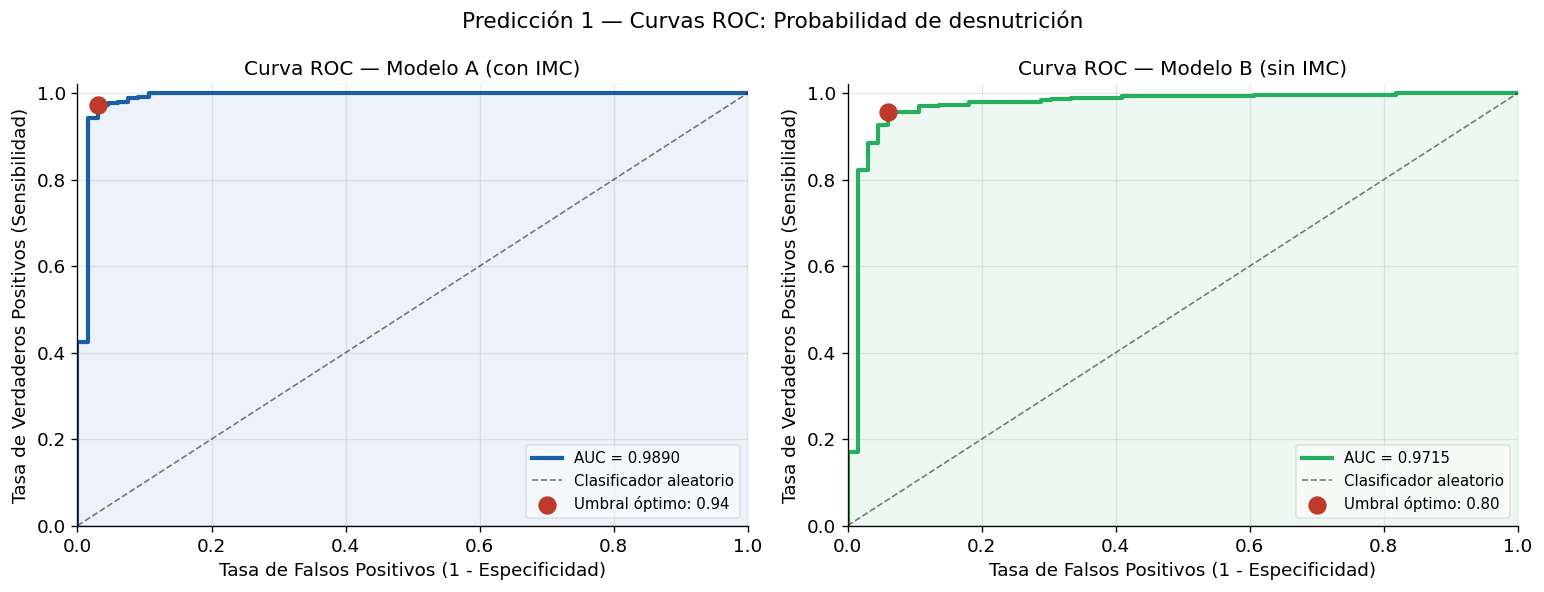

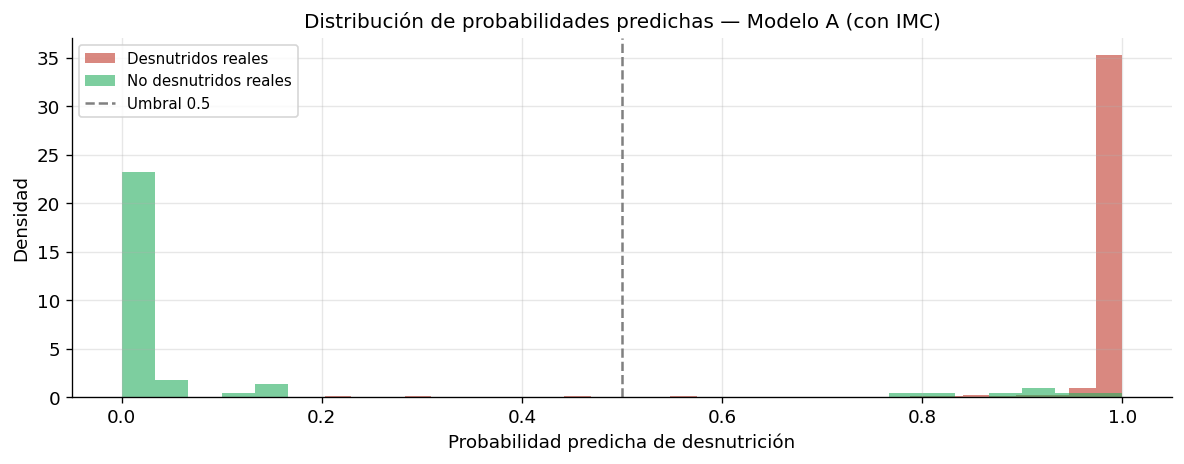

Ideal: las dos distribuciones bien separadas → el modelo discrimina bien.
Si se solapan mucho → el modelo tiene dificultad en casos ambiguos.


In [21]:
# Curvas ROC
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, prob, auc, nombre, color in [
    (axes[0], prob_A, auc_A, 'Modelo A (con IMC)', '#185fa5'),
    (axes[1], prob_B, auc_B, 'Modelo B (sin IMC)', '#27ae60'),
]:
    fpr, tpr, umbrales = roc_curve(yte_bin, prob)
    ax.plot(fpr, tpr, color=color, linewidth=2.5, label=f'AUC = {auc:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Clasificador aleatorio')
    # Punto óptimo (umbral con mejor balance sensibilidad/especificidad)
    j_scores = tpr - fpr
    idx_opt  = np.argmax(j_scores)
    ax.scatter(fpr[idx_opt], tpr[idx_opt], s=100, color='#c0392b', zorder=5,
               label=f'Umbral óptimo: {umbrales[idx_opt]:.2f}')
    ax.fill_between(fpr, tpr, alpha=0.08, color=color)
    ax.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
    ax.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
    ax.set_title(f'Curva ROC — {nombre}', fontsize=12)
    ax.legend(fontsize=9, framealpha=0.5)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)

plt.suptitle('Predicción 1 — Curvas ROC: Probabilidad de desnutrición', fontsize=13)
plt.tight_layout()
plt.show()

# Distribución de probabilidades predichas
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(prob_A[yte_bin==1], bins=30, alpha=0.6, color='#c0392b',
        label='Desnutridos reales', density=True)
ax.hist(prob_A[yte_bin==0], bins=30, alpha=0.6, color='#27ae60',
        label='No desnutridos reales', density=True)
ax.axvline(0.5, color='gray', linestyle='--', linewidth=1.5, label='Umbral 0.5')
ax.set_title('Distribución de probabilidades predichas — Modelo A (con IMC)', fontsize=12)
ax.set_xlabel('Probabilidad predicha de desnutrición')
ax.set_ylabel('Densidad')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print('Ideal: las dos distribuciones bien separadas → el modelo discrimina bien.')
print('Si se solapan mucho → el modelo tiene dificultad en casos ambiguos.')

In [22]:
# Ejemplos de casos con probabilidad alta y baja
# Nota: municipio_origen viene de df_full (no está en dataset_ml)
df_e = df_ml[FEATURES_A + ['desnutrido','clas_peso']].copy()
df_e['edad_meses'] = df_ml.apply(
    lambda r: r['edad_']*12 if r['uni_med_']==1 else r['edad_'], axis=1)
df_e['municipio_origen'] = df_full['municipio_origen'].values[:len(df_e)]

le_e = LabelEncoder()
df_e['cod_dpto_o'] = le_e.fit_transform(df_e['cod_dpto_o'].astype(str))
for col in ['niv_educat','gp_pobicbf','menores','per_braqui']:
    df_e[col] = df_e[col].fillna(df_e[col].median())

X_e = df_e[FEATURES_A].copy()
X_e[COLS_ESCALAR] = scaler_A.transform(X_e[COLS_ESCALAR])
df_e['prob_desnutricion'] = gb_bin_A.predict_proba(X_e)[:, 1]

print('Casos con probabilidad MÁS ALTA de desnutrición (top 5):')
top_alto = df_e.nlargest(5, 'prob_desnutricion')[
    ['municipio_origen','edad_meses','peso_act','per_braqui','prob_desnutricion','clas_peso']]
print(top_alto.round(3).to_string(index=False))

print('\nCasos con probabilidad MÁS BAJA de desnutrición (top 5):')
top_bajo = df_e.nsmallest(5, 'prob_desnutricion')[
    ['municipio_origen','edad_meses','peso_act','per_braqui','prob_desnutricion','clas_peso']]
print(top_bajo.round(3).to_string(index=False))

Casos con probabilidad MÁS ALTA de desnutrición (top 5):
municipio_origen  edad_meses  peso_act  per_braqui  prob_desnutricion  clas_peso
          Uribia          11       6.1        12.0                1.0          1
      Valledupar          24       6.3        12.8                1.0          1
      Valledupar          24       8.2        12.5                1.0          2
          Maicao          24       8.4        12.1                1.0          2
          Uribia          24       8.7        12.5                1.0          2

Casos con probabilidad MÁS BAJA de desnutrición (top 5):
municipio_origen  edad_meses  peso_act  per_braqui  prob_desnutricion  clas_peso
 Agustin Codazzi          36      13.4        14.0                0.0          5
          Uribia           4       4.1        12.0                0.0          5
    Pueblo Bello           5       4.2        12.0                0.0          4
          Maicao           2       3.9        12.0                0.0      

---
# PREDICCIÓN 2 — Perfil de riesgo poblacional

**¿Qué hace?**  
Identifica qué combinaciones de factores (área, etnia, vacunación, seguimiento)
generan mayor riesgo de desnutrición. Responde preguntas como:
*"¿Cuánto más riesgo tiene un niño indígena rural sin seguimiento C&D?"*

**¿Por qué es útil?**  
Permite a la Secretaría de Salud **focalizar intervenciones** en los grupos
más vulnerables en lugar de hacer campañas generales.

In [23]:
# Calcular tasa de desnutrición por combinaciones de factores
mapa_area    = {1: 'Cabecera', 2: 'C. Poblado', 3: 'Rural'}
mapa_etnia   = {1: 'Indígena', 2: 'Rom/Gitano', 3: 'Raizal',
                4: 'Palenquero', 5: 'Afrocolombiano', 6: 'Otro'}
mapa_vac     = {1: 'Vacun. completa', 2: 'Vacun. incompleta', 3: 'Sin vacunación'}
mapa_crec    = {1: 'Con seguimiento', 2: 'Sin seguimiento'}

df_full['area_label']  = df_full['area_'].map(mapa_area)
df_full['etnia_label'] = df_full['per_etn_'].map(mapa_etnia)
df_full['vac_label']   = df_full['esq_vac'].map(mapa_vac)
df_full['crec_label']  = df_full['crec_dllo'].map(mapa_crec)

# Perfil por área + etnia
perfil_area_etnia = (df_full.groupby(['area_label','etnia_label'])
    .agg(n=('desnutrido','count'), tasa=('desnutrido','mean'))
    .reset_index()
    .query('n >= 15')
    .sort_values('tasa', ascending=False))

print('Tasa de desnutrición por área y etnia (mín. 15 casos):')
print(perfil_area_etnia.round(3).to_string(index=False))

Tasa de desnutrición por área y etnia (mín. 15 casos):
area_label etnia_label    n  tasa
  Cabecera        Otro  136 0.926
  Cabecera    Indígena  325 0.920
C. Poblado        Otro   26 0.885
     Rural    Indígena 1791 0.855
C. Poblado    Indígena  112 0.830
     Rural        Otro   46 0.739


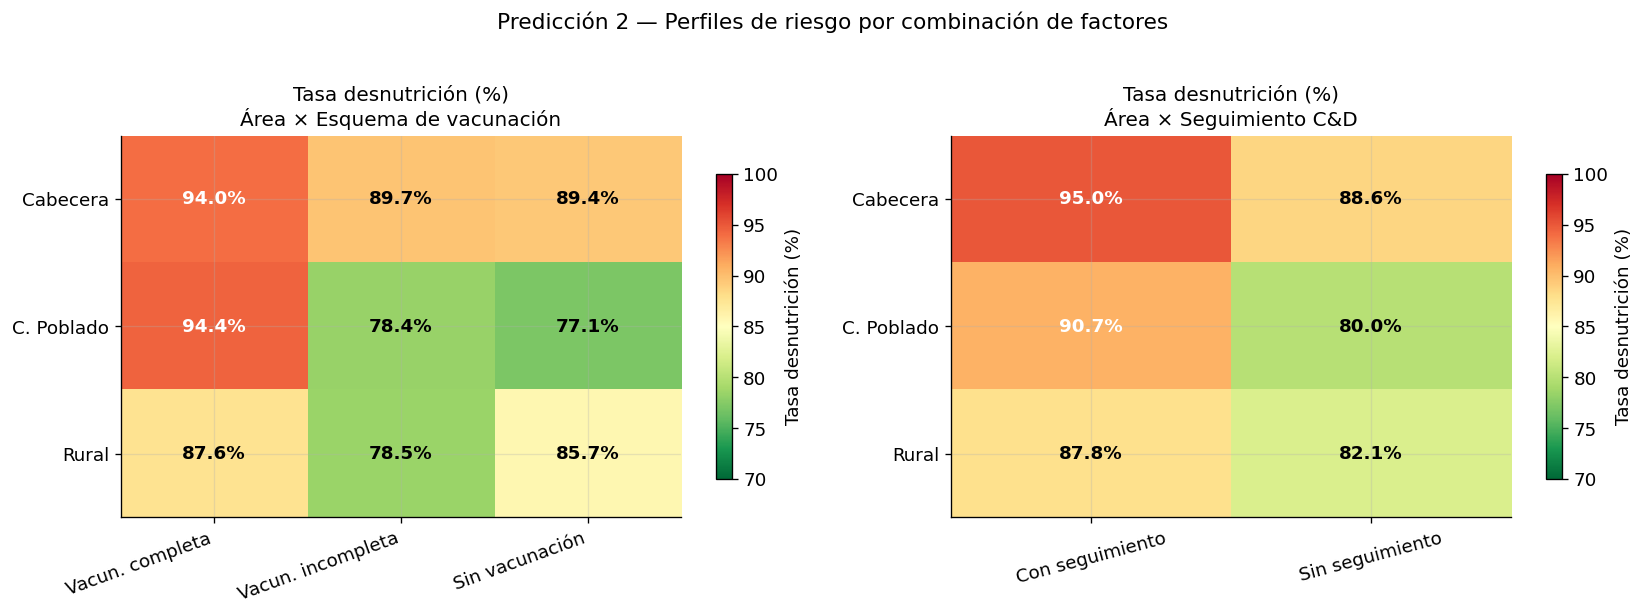

In [24]:
# Heatmap: área × vacunación
pivot_vac = (df_full.groupby(['area_label','vac_label'])['desnutrido']
             .mean().unstack() * 100)
pivot_vac = pivot_vac.reindex(index=['Cabecera','C. Poblado','Rural'],
                               columns=['Vacun. completa','Vacun. incompleta','Sin vacunación'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap área × vacunación
im1 = axes[0].imshow(pivot_vac.values, cmap='RdYlGn_r', vmin=70, vmax=100, aspect='auto')
plt.colorbar(im1, ax=axes[0], shrink=0.8, label='Tasa desnutrición (%)')
axes[0].set_xticks(range(len(pivot_vac.columns)))
axes[0].set_yticks(range(len(pivot_vac.index)))
axes[0].set_xticklabels(pivot_vac.columns, rotation=20, ha='right')
axes[0].set_yticklabels(pivot_vac.index)
for i in range(len(pivot_vac.index)):
    for j in range(len(pivot_vac.columns)):
        val = pivot_vac.values[i, j]
        if not np.isnan(val):
            axes[0].text(j, i, f'{val:.1f}%', ha='center', va='center',
                        fontsize=11, fontweight='bold',
                        color='white' if val > 90 else 'black')
axes[0].set_title('Tasa desnutrición (%)\nÁrea × Esquema de vacunación', fontsize=12)

# Heatmap área × seguimiento C&D
pivot_crec = (df_full.groupby(['area_label','crec_label'])['desnutrido']
              .mean().unstack() * 100)
pivot_crec = pivot_crec.reindex(index=['Cabecera','C. Poblado','Rural'])
im2 = axes[1].imshow(pivot_crec.values, cmap='RdYlGn_r', vmin=70, vmax=100, aspect='auto')
plt.colorbar(im2, ax=axes[1], shrink=0.8, label='Tasa desnutrición (%)')
axes[1].set_xticks(range(len(pivot_crec.columns)))
axes[1].set_yticks(range(len(pivot_crec.index)))
axes[1].set_xticklabels(pivot_crec.columns, rotation=15)
axes[1].set_yticklabels(pivot_crec.index)
for i in range(len(pivot_crec.index)):
    for j in range(len(pivot_crec.columns)):
        val = pivot_crec.values[i, j]
        if not np.isnan(val):
            axes[1].text(j, i, f'{val:.1f}%', ha='center', va='center',
                        fontsize=11, fontweight='bold',
                        color='white' if val > 90 else 'black')
axes[1].set_title('Tasa desnutrición (%)\nÁrea × Seguimiento C&D', fontsize=12)

plt.suptitle('Predicción 2 — Perfiles de riesgo por combinación de factores',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [25]:
# Ranking de perfiles de riesgo completo
perfiles = (df_full.groupby(['area_label','etnia_label','vac_label','crec_label'])
    .agg(n=('desnutrido','count'), tasa_desnut=('desnutrido','mean'),
         zscore_medio=('zscore_pt','mean'), peso_medio=('peso_act','mean'))
    .reset_index()
    .query('n >= 20')
    .sort_values('tasa_desnut', ascending=False)
    .round(3))

print('TOP 10 perfiles de MAYOR riesgo (mín. 20 casos):')
print(perfiles.head(10).to_string(index=False))
print()
print('TOP 5 perfiles de MENOR riesgo:')
print(perfiles.tail(5).to_string(index=False))
print()
print('Interpretación: Los perfiles con tasa_desnut > 0.90 son grupos prioritarios')
print('para intervención focalizada de la Secretaría de Salud.')

TOP 10 perfiles de MAYOR riesgo (mín. 20 casos):
area_label etnia_label         vac_label      crec_label   n  tasa_desnut  zscore_medio  peso_medio
C. Poblado    Indígena   Vacun. completa Con seguimiento  26        1.000        -2.551       7.965
  Cabecera        Otro   Vacun. completa Con seguimiento  67        0.970        -2.368       9.050
  Cabecera    Indígena   Vacun. completa Con seguimiento 150        0.940        -2.426       7.951
  Cabecera        Otro   Vacun. completa Sin seguimiento  27        0.926        -2.647       7.705
  Cabecera    Indígena    Sin vacunación Sin seguimiento  60        0.900        -2.705       7.003
     Rural    Indígena   Vacun. completa Con seguimiento 669        0.894        -2.237       7.758
  Cabecera    Indígena   Vacun. completa Sin seguimiento  36        0.889        -2.518       6.595
     Rural    Indígena    Sin vacunación Con seguimiento 160        0.875        -2.335       7.867
     Rural    Indígena    Sin vacunación Sin seguim

---
# PREDICCIÓN 3 — Municipios de alto riesgo

**¿Qué hace?**  
Rankea los municipios según su tasa de desnutrición histórica e identifica
cuáles necesitan intervención prioritaria.

**¿Por qué es útil?**  
Permite asignar recursos de salud pública de forma focalizada —
no todos los municipios tienen el mismo nivel de crisis.

In [26]:
# Calcular métricas por municipio
MIN_CASOS = 20
mun_stats = (df_full.groupby('municipio_origen')
    .agg(
        casos        = ('desnutrido','count'),
        tasa_desnut  = ('desnutrido','mean'),
        tasa_severa  = ('clas_peso', lambda x: (x==1).mean()),
        zscore_medio = ('zscore_pt','mean'),
        peso_medio   = ('peso_act','mean'),
        pct_rural    = ('area_', lambda x: (x==3).mean()),
        pct_indigena = ('per_etn_', lambda x: (x==1).mean()),
    )
    .query(f'casos >= {MIN_CASOS}')
    .sort_values('tasa_desnut', ascending=False)
    .round(3)
)
mun_stats['tasa_desnut_pct'] = (mun_stats['tasa_desnut'] * 100).round(1)
mun_stats['tasa_severa_pct'] = (mun_stats['tasa_severa'] * 100).round(1)

print(f'Municipios con mínimo {MIN_CASOS} casos: {len(mun_stats)}')
print()
print('Ranking completo de municipios por tasa de desnutrición:')
print(mun_stats[['casos','tasa_desnut_pct','tasa_severa_pct','zscore_medio',
                  'peso_medio','pct_rural','pct_indigena']].to_string())

Municipios con mínimo 20 casos: 12

Ranking completo de municipios por tasa de desnutrición:
                    casos  tasa_desnut_pct  tasa_severa_pct  zscore_medio  peso_medio  pct_rural  pct_indigena
municipio_origen                                                                                              
Barrancas              20            100.0             15.0        -2.591       8.305      0.650         0.800
Manaure               248             96.4             12.1        -2.420       7.667      0.782         0.988
Agustin Codazzi       415             95.4             12.5        -2.513       7.467      0.904         0.971
Uribia                514             94.9             13.2        -2.428       7.684      0.800         0.990
Maicao                242             91.3             12.4        -2.325       7.374      0.694         0.860
Cienaga                45             91.1             55.6        -3.316       6.036      0.178         0.933
Albania            

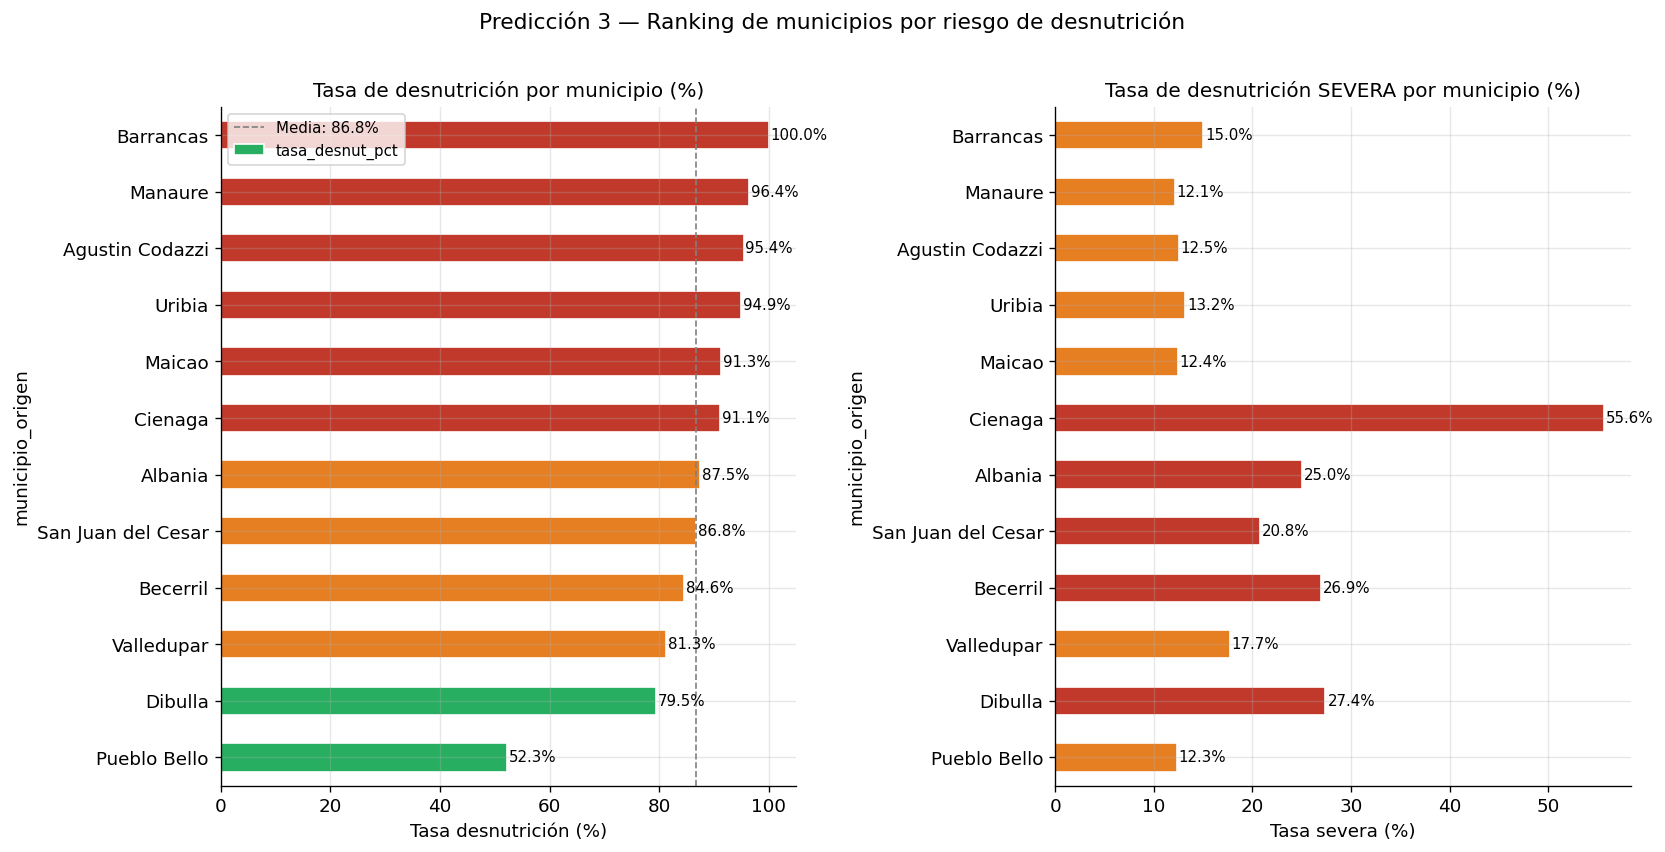


Municipios CRÍTICOS (tasa ≥ 90%):
                  casos  tasa_desnut_pct  tasa_severa_pct  pct_rural  pct_indigena
municipio_origen                                                                  
Barrancas            20            100.0             15.0      0.650         0.800
Manaure             248             96.4             12.1      0.782         0.988
Agustin Codazzi     415             95.4             12.5      0.904         0.971
Uribia              514             94.9             13.2      0.800         0.990
Maicao              242             91.3             12.4      0.694         0.860
Cienaga              45             91.1             55.6      0.178         0.933


In [27]:
# Gráfico ranking municipios
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Tasa de desnutrición
colores_mun = ['#c0392b' if v >= 90 else '#e67e22' if v >= 80 else '#27ae60'
               for v in mun_stats['tasa_desnut_pct'].values]
mun_stats['tasa_desnut_pct'][::-1].plot(kind='barh', ax=axes[0],
                                          color=colores_mun[::-1], edgecolor='white')
for p in axes[0].patches:
    axes[0].text(p.get_width() + 0.3, p.get_y() + p.get_height()/2,
                 f'{p.get_width():.1f}%', va='center', fontsize=9)
axes[0].axvline(mun_stats['tasa_desnut_pct'].mean(), color='gray', linestyle='--',
                linewidth=1, label=f'Media: {mun_stats["tasa_desnut_pct"].mean():.1f}%')
axes[0].set_title('Tasa de desnutrición por municipio (%)', fontsize=12)
axes[0].set_xlabel('Tasa desnutrición (%)')
axes[0].legend(fontsize=9)

# Tasa severa
colores_sev = ['#c0392b' if v >= 20 else '#e67e22' if v >= 10 else '#27ae60'
               for v in mun_stats['tasa_severa_pct'].values]
mun_stats['tasa_severa_pct'][::-1].plot(kind='barh', ax=axes[1],
                                          color=colores_sev[::-1], edgecolor='white')
for p in axes[1].patches:
    axes[1].text(p.get_width() + 0.2, p.get_y() + p.get_height()/2,
                 f'{p.get_width():.1f}%', va='center', fontsize=9)
axes[1].set_title('Tasa de desnutrición SEVERA por municipio (%)', fontsize=12)
axes[1].set_xlabel('Tasa severa (%)')

plt.suptitle('Predicción 3 — Ranking de municipios por riesgo de desnutrición',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('\nMunicipios CRÍTICOS (tasa ≥ 90%):')
criticos = mun_stats[mun_stats['tasa_desnut_pct'] >= 90]
print(criticos[['casos','tasa_desnut_pct','tasa_severa_pct','pct_rural','pct_indigena']].to_string())

---
# PREDICCIÓN 4 — Evolución temporal y proyección 2026

**¿Qué hace?**  
Analiza la tendencia histórica 2023-2025 y proyecta cómo evolucionará
la tasa de desnutrición en los próximos 6 meses.

**¿Por qué es útil?**  
Permite a la Secretaría de Salud anticipar la demanda de atención y
planificar recursos con anticipación.

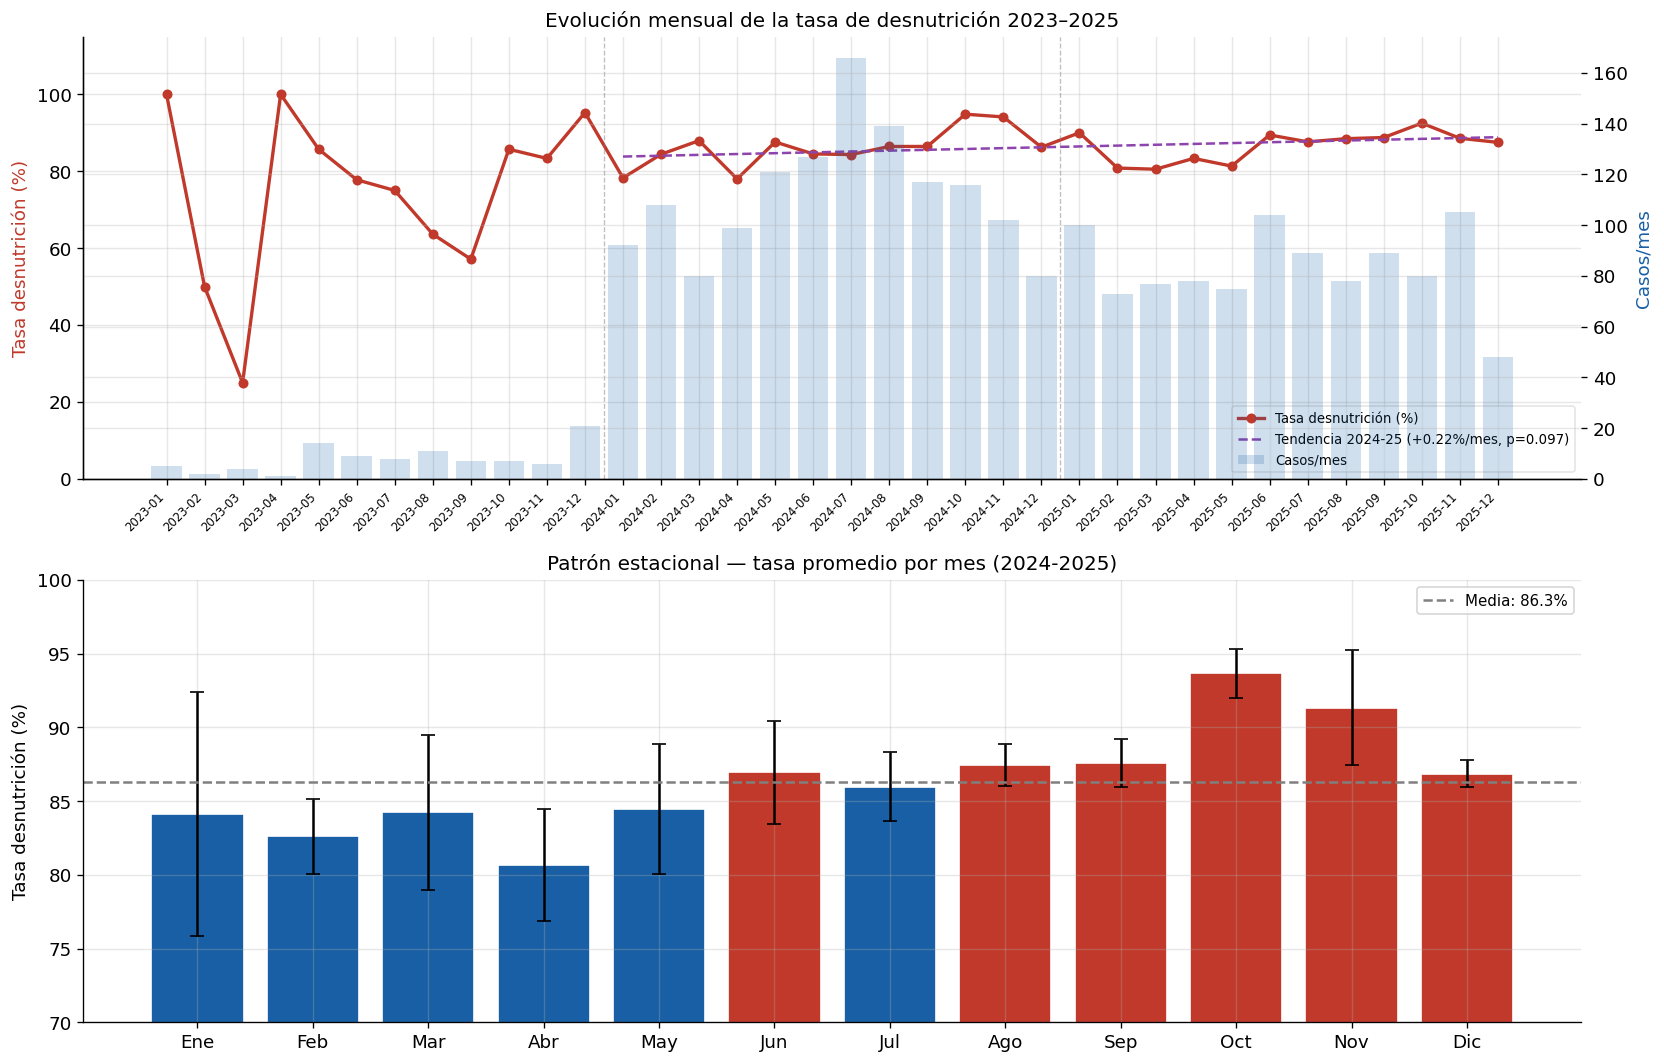

Tendencia 2024-2025: +0.2191%/mes (p=0.0975)
No significativa — la tasa se mantiene estable sin mejora clara

Mes con mayor tasa: Oct (93.7%)
Mes con menor tasa: Abr (80.7%)


In [28]:
# ── Tendencia y estacionalidad ────────────────────────────────────────────
st_estable = st[st['anio_mes'] >= '2024-01'].copy().reset_index(drop=True)
st_estable['t']   = np.arange(len(st_estable))
st_estable['mes'] = st_estable['fecha'].dt.month

slope, intercept, r_val, p_val, _ = scipy_stats.linregress(
    st_estable['t'], st_estable['tasa_desnut'])

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Gráfico 1: Serie completa con tendencia
ax1 = axes[0]
ax2 = ax1.twinx()
ax2.bar(range(len(st)), st['casos'], color='#185fa5', alpha=0.2, label='Casos/mes')
ax1.plot(range(len(st)), st['tasa_desnut'], 'o-', color='#c0392b',
         linewidth=2, markersize=5, label='Tasa desnutrición (%)')
idx_start = st[st['anio_mes'] == '2024-01'].index[0]
x_est = st_estable['t'].values.reshape(-1,1)
from sklearn.linear_model import LinearRegression
lr = LinearRegression().fit(x_est, st_estable['tasa_desnut'])
tend = lr.predict(x_est)
ax1.plot(range(idx_start, idx_start+len(tend)), tend, '--', color='#8e44ad',
         linewidth=1.5, label=f'Tendencia 2024-25 ({slope:+.2f}%/mes, p={p_val:.3f})')
for yr_idx in [12, 24]:
    ax1.axvline(yr_idx-0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax1.set_xticks(range(len(st)))
ax1.set_xticklabels(st['anio_mes'], rotation=45, ha='right', fontsize=7)
ax1.set_ylabel('Tasa desnutrición (%)', color='#c0392b')
ax2.set_ylabel('Casos/mes', color='#185fa5')
ax1.set_ylim(0, 115)
ax1.set_title('Evolución mensual de la tasa de desnutrición 2023–2025', fontsize=12)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='lower right', fontsize=8, framealpha=0.5)

# Gráfico 2: Estacionalidad
meses_label = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
media_mes = st_estable.groupby('mes')['tasa_desnut'].mean()
std_mes   = st_estable.groupby('mes')['tasa_desnut'].std()
colores_mes = ['#c0392b' if v >= media_mes.mean() else '#185fa5' for v in media_mes.values]
axes[1].bar(range(1,13), media_mes.values, color=colores_mes, edgecolor='white')
axes[1].errorbar(range(1,13), media_mes.values, yerr=std_mes.values,
                 fmt='none', color='black', capsize=4)
axes[1].axhline(media_mes.mean(), color='gray', linestyle='--',
                label=f'Media: {media_mes.mean():.1f}%')
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(meses_label)
axes[1].set_ylim(70, 100)
axes[1].set_title('Patrón estacional — tasa promedio por mes (2024-2025)', fontsize=12)
axes[1].set_ylabel('Tasa desnutrición (%)')
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Tendencia 2024-2025: {slope:+.4f}%/mes (p={p_val:.4f})')
print(f'{"Significativa" if p_val < 0.05 else "No significativa"} — la tasa se mantiene estable sin mejora clara')
print(f'\nMes con mayor tasa: {meses_label[media_mes.values.argmax()]} ({media_mes.max():.1f}%)')
print(f'Mes con menor tasa: {meses_label[media_mes.values.argmin()]} ({media_mes.min():.1f}%)')

SARIMA ajustado ✅


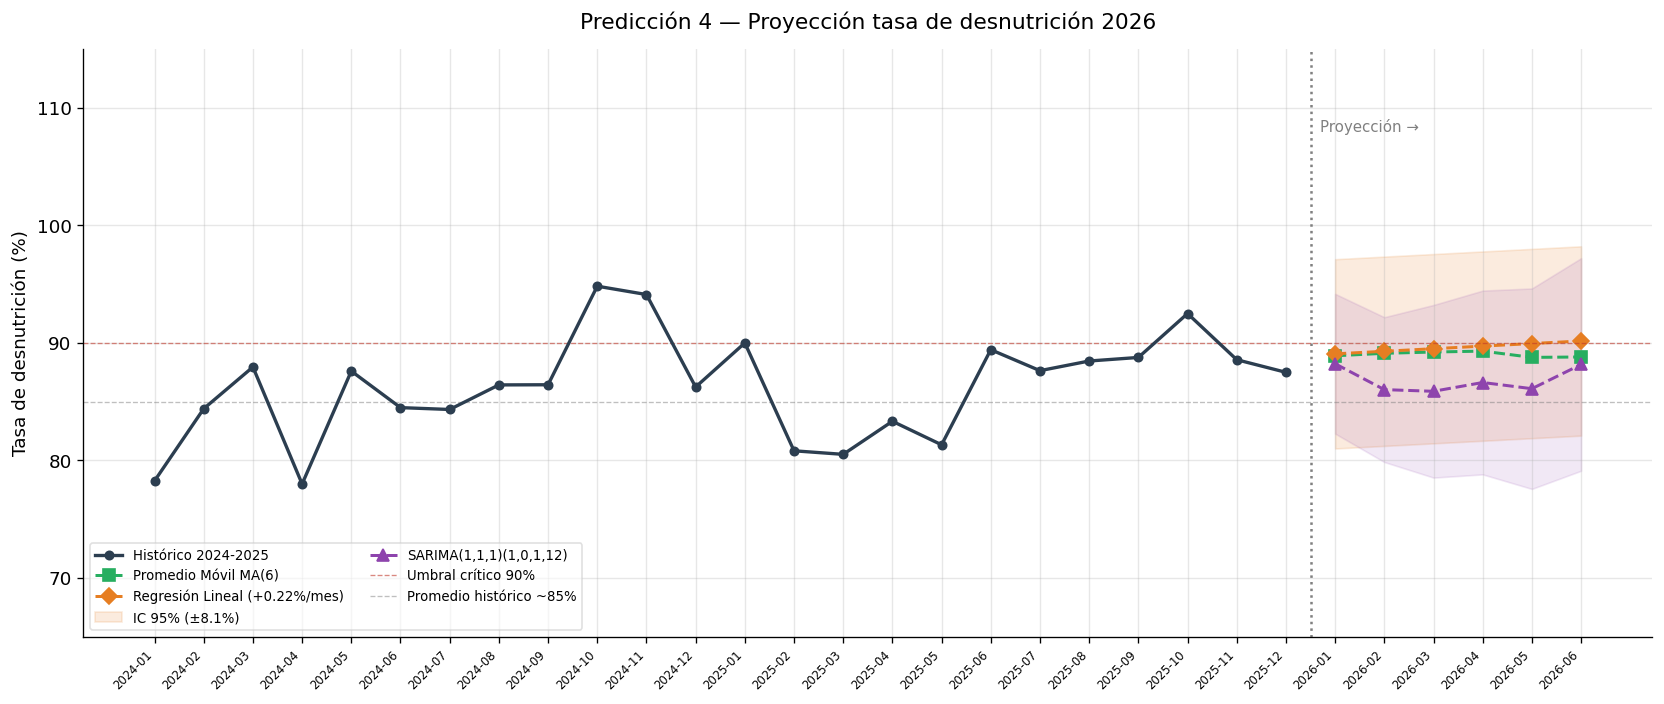


Resumen proyección 2026:
    Mes  MA(6)  Reg.Lineal  SARIMA
2026-01   88.9        89.1    88.2
2026-02   89.1        89.3    86.0
2026-03   89.2        89.5    85.9
2026-04   89.3        89.7    86.6
2026-05   88.8        89.9    86.1
2026-06   88.8        90.2    88.2

Proyección central: 89.0% — sin mejora significativa esperada


In [29]:
# ── Proyección 2026 ───────────────────────────────────────────────────────
STEPS = 6
ultima_fecha  = st['fecha'].max()
fechas_futuras = pd.date_range(start=ultima_fecha + pd.DateOffset(months=1),
                                periods=STEPS, freq='MS')
meses_futuros = [f.strftime('%Y-%m') for f in fechas_futuras]

# Promedio móvil MA(6)
def ma_forecast(serie, window, steps):
    hist = list(serie)
    preds = []
    for _ in range(steps):
        p = np.mean(hist[-window:])
        preds.append(p)
        hist.append(p)
    return preds

preds_ma6 = ma_forecast(st_estable['tasa_desnut'].values, window=6, steps=STEPS)

# Regresión lineal
t_max   = st_estable['t'].max()
t_fut   = np.arange(t_max+1, t_max+STEPS+1).reshape(-1,1)
preds_lr = lr.predict(t_fut)
std_res  = np.std(st_estable['tasa_desnut'].values - lr.predict(x_est))
ic_95    = 1.96 * std_res

# SARIMA si disponible
SARIMA_OK = False
try:
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    sarima = SARIMAX(st_estable['tasa_desnut'].values,
                     order=(1,1,1), seasonal_order=(1,0,1,12),
                     enforce_stationarity=False, enforce_invertibility=False)
    res_sarima = sarima.fit(disp=False)
    fc = res_sarima.get_forecast(steps=STEPS)
    preds_sarima  = np.asarray(fc.predicted_mean)
    ic_sarima_raw = fc.conf_int(alpha=0.05)
    ic_sarima_lo  = np.asarray(ic_sarima_raw.iloc[:, 0]) if hasattr(ic_sarima_raw, 'iloc') else np.asarray(ic_sarima_raw[:, 0])
    ic_sarima_hi  = np.clip(np.asarray(ic_sarima_raw.iloc[:, 1]) if hasattr(ic_sarima_raw, 'iloc') else np.asarray(ic_sarima_raw[:, 1]), None, 100)
    SARIMA_OK     = True
    print('SARIMA ajustado ✅')
except ImportError:
    print('statsmodels no disponible — usando MA y regresión lineal')

# Gráfico proyección
fig, ax = plt.subplots(figsize=(14, 6))
idx_2024 = st[st['anio_mes']=='2024-01'].index[0]
hist_x = list(range(idx_2024, len(st)))
hist_y = st.loc[idx_2024:, 'tasa_desnut'].values
ax.plot(hist_x, hist_y, 'o-', color='#2c3e50', linewidth=2, markersize=5,
        label='Histórico 2024-2025', zorder=5)
ax.axvline(len(st)-0.5, color='gray', linestyle=':', linewidth=1.5)
ax.text(len(st)-0.3, 108, 'Proyección →', fontsize=9, color='gray')
x_fut = list(range(len(st), len(st)+STEPS))
ax.plot(x_fut, preds_ma6, 's--', color='#27ae60', linewidth=1.8, markersize=7,
        label='Promedio Móvil MA(6)')
ax.plot(x_fut, preds_lr, 'D--', color='#e67e22', linewidth=1.8, markersize=7,
        label=f'Regresión Lineal ({slope:+.2f}%/mes)')
ax.fill_between(x_fut, [p-ic_95 for p in preds_lr],
                [min(p+ic_95,100) for p in preds_lr],
                alpha=0.15, color='#e67e22', label=f'IC 95% (±{ic_95:.1f}%)')
if SARIMA_OK:
    ax.plot(x_fut, np.asarray(preds_sarima), '^--', color='#8e44ad', linewidth=1.8,
            markersize=7, label='SARIMA(1,1,1)(1,0,1,12)')
    ax.fill_between(x_fut, ic_sarima_lo, ic_sarima_hi,
                    alpha=0.12, color='#8e44ad')
ax.axhline(90, color='#c0392b', linestyle='--', linewidth=0.8, alpha=0.6,
           label='Umbral crítico 90%')
ax.axhline(85, color='gray', linestyle='--', linewidth=0.8, alpha=0.5,
           label='Promedio histórico ~85%')
todos_x = hist_x + x_fut
todas_labels = list(st.loc[idx_2024:,'anio_mes']) + meses_futuros
ax.set_xticks(todos_x)
ax.set_xticklabels(todas_labels, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Tasa de desnutrición (%)')
ax.set_ylim(65, 115)
ax.set_title('Predicción 4 — Proyección tasa de desnutrición 2026', fontsize=13, pad=12)
ax.legend(loc='lower left', framealpha=0.6, fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

print('\nResumen proyección 2026:')
df_proj = pd.DataFrame({'Mes': meses_futuros,
                         'MA(6)': [round(p,1) for p in preds_ma6],
                         'Reg.Lineal': [round(p,1) for p in preds_lr]})
if SARIMA_OK:
    df_proj['SARIMA'] = np.asarray(preds_sarima).round(1)
print(df_proj.to_string(index=False))
print(f'\nProyección central: {np.mean(preds_ma6):.1f}% — sin mejora significativa esperada')

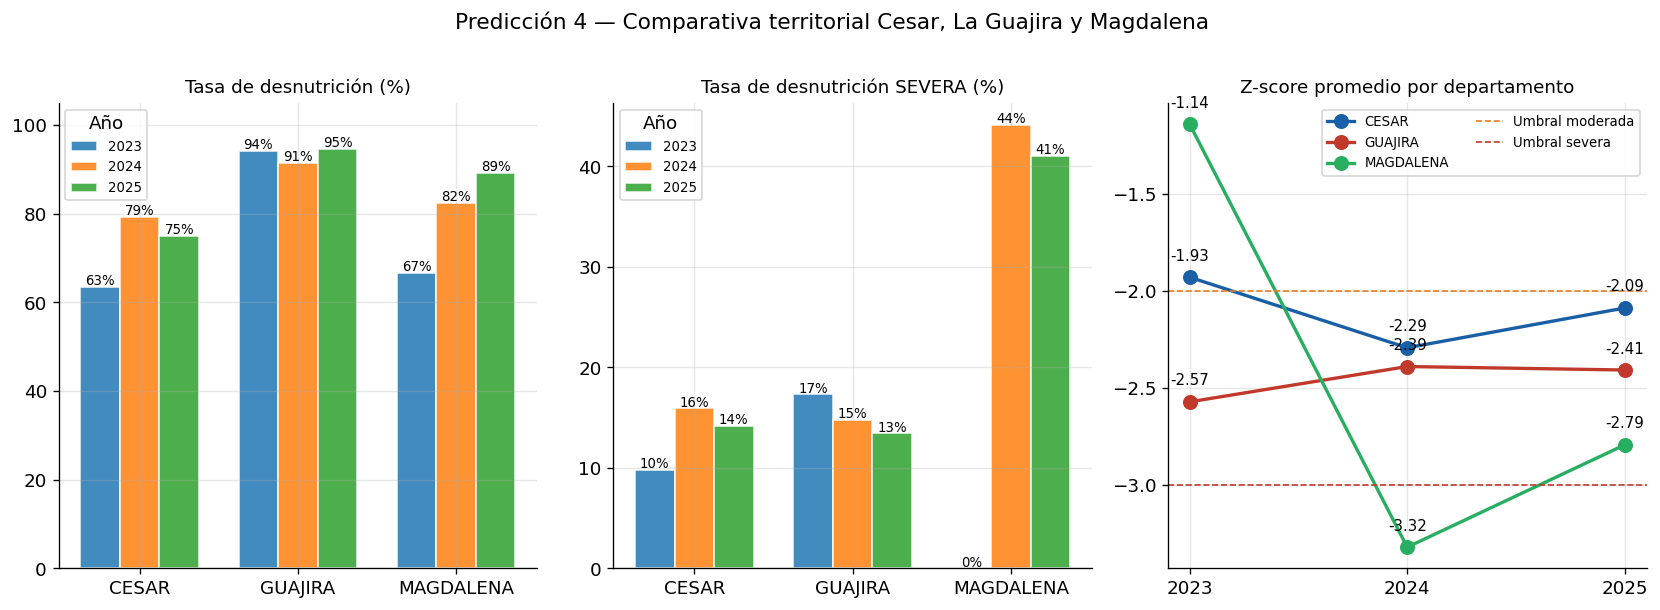


Hallazgos territoriales:
2024: La Guajira supera al Cesar en +12.0 puntos de tasa de desnutrición
2025: La Guajira supera al Cesar en +19.6 puntos de tasa de desnutrición


In [30]:
# ── Comparativa territorial ───────────────────────────────────────────────
dptos = ['CESAR','GUAJIRA','MAGDALENA']
sd_main = sd[sd['departamento'].isin(dptos)].copy()
COLORES_DPTO = {'CESAR':'#185fa5','GUAJIRA':'#c0392b','MAGDALENA':'#27ae60'}
anios = sorted(sd_main['anio'].unique())

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Tasa total
ax = axes[0]
x = np.arange(len(dptos))
width = 0.25
for i, anio in enumerate(anios):
    vals = [sd_main[(sd_main['anio']==anio)&(sd_main['departamento']==d)]['tasa_desnut'].values[0]
            if len(sd_main[(sd_main['anio']==anio)&(sd_main['departamento']==d)])>0 else np.nan
            for d in dptos]
    offset = (i-(len(anios)-1)/2)*width
    bars = ax.bar(x+offset, vals, width, label=str(anio), edgecolor='white', alpha=0.85)
    for j,v in enumerate(vals):
        if not np.isnan(v):
            ax.text(x[j]+offset, v+0.5, f'{v:.0f}%', ha='center', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(dptos)
ax.set_title('Tasa de desnutrición (%)', fontsize=11)
ax.set_ylim(0, 105)
ax.legend(title='Año', fontsize=8)

# Tasa severa
ax = axes[1]
for i, anio in enumerate(anios):
    vals = [sd_main[(sd_main['anio']==anio)&(sd_main['departamento']==d)]['tasa_severa'].values[0]
            if len(sd_main[(sd_main['anio']==anio)&(sd_main['departamento']==d)])>0 else np.nan
            for d in dptos]
    offset = (i-(len(anios)-1)/2)*width
    bars = ax.bar(x+offset, vals, width, label=str(anio), edgecolor='white', alpha=0.85)
    for j,v in enumerate(vals):
        if not np.isnan(v):
            ax.text(x[j]+offset, v+0.2, f'{v:.0f}%', ha='center', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(dptos)
ax.set_title('Tasa de desnutrición SEVERA (%)', fontsize=11)
ax.legend(title='Año', fontsize=8)

# Z-score evolución
ax = axes[2]
for dpto in dptos:
    sub = sd_main[sd_main['departamento']==dpto].sort_values('anio')
    ax.plot(sub['anio'], sub['zscore_medio'], 'o-',
            color=COLORES_DPTO[dpto], linewidth=2, markersize=8, label=dpto)
    for _, row in sub.iterrows():
        ax.annotate(f'{row["zscore_medio"]:.2f}', (row['anio'],row['zscore_medio']),
                    textcoords='offset points', xytext=(0,10), ha='center', fontsize=9)
ax.axhline(-2, color='#e67e22', linestyle='--', linewidth=1, label='Umbral moderada')
ax.axhline(-3, color='#c0392b', linestyle='--', linewidth=1, label='Umbral severa')
ax.set_title('Z-score promedio por departamento', fontsize=11)
ax.set_xticks(anios)
ax.legend(fontsize=8, ncol=2)

plt.suptitle('Predicción 4 — Comparativa territorial Cesar, La Guajira y Magdalena',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('\nHallazgos territoriales:')
for anio in [2024,2025]:
    c = sd_main[(sd_main['departamento']=='CESAR')&(sd_main['anio']==anio)]
    g = sd_main[(sd_main['departamento']=='GUAJIRA')&(sd_main['anio']==anio)]
    if len(c)>0 and len(g)>0:
        diff = g['tasa_desnut'].values[0] - c['tasa_desnut'].values[0]
        print(f'{anio}: La Guajira supera al Cesar en {diff:+.1f} puntos de tasa de desnutrición')

---
## Resumen de predicciones

| Predicción | Pregunta que responde | Utilidad |
|---|---|---|
| **1 — Probabilidad individual** | ¿Qué % de riesgo tiene este niño? | Priorizar atención en consulta |
| **2 — Perfil de riesgo** | ¿Qué combinación de factores es más peligrosa? | Focalizar campañas preventivas |
| **3 — Municipios críticos** | ¿Dónde hay más urgencia de intervención? | Asignar recursos territorialmente |
| **4 — Proyección temporal** | ¿Cómo evolucionará la situación en 2026? | Planificar capacidad de atención |

### Hallazgos clave

- **Predicción 1:** AUC de 0.989 (con IMC) y 0.971 (sin IMC) — el modelo discrimina muy bien
- **Predicción 2:** Comunidades indígenas rurales sin vacunación tienen tasas > 90%
- **Predicción 3:** Barrancas, Manaure, Agustín Codazzi y Uribia son municipios críticos
- **Predicción 4:** La tasa se proyecta estable ~87-90% sin intervenciones estructurales

### Limitaciones
- La probabilidad individual alta no implica causalidad — son correlaciones estadísticas
- Los perfiles de riesgo son descriptivos, no deterministas
- La proyección temporal tiene IC ±8-10% por pocos puntos en la serie